## DBSCAN vs K-Means

Two different ways to group the locations:

- **K-Means** partitions *every* point into exactly `k` clusters — you tell it how many colonies to expect. It has no concept of noise, so stray rats get forced into the nearest colony.
- **DBSCAN** groups points by *density*. It finds however many clusters exist on its own and labels low-density locations as noise (`-1`).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans, DBSCAN

In [2]:
# 2.Data

np.random.seed(42)

cluster1 = np.random.normal(
    loc=[40, 40],   # center
    scale=[6, 4],  # spread
    size=(20, 2)
)


cluster2 = np.random.normal(
    loc=[80, 30],
    scale=[4, 6],
    size=(20, 2)
)


noise = np.random.uniform(
    low=[0, 0],
    high=[120, 100],
    size=(10, 2)
)


rats = np.vstack([cluster1, cluster2, noise])


df = pd.DataFrame(
    rats,
    columns=["x_location", "y_location"]
)

df["rat_id"] = range(1, 51)

In [3]:
X = df[["x_location", "y_location"]].values

# K-Means: we must tell it how many clusters to find
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
df["kmeans_label"] = kmeans.fit_predict(X)

# DBSCAN: finds clusters by density; -1 means "noise / stray rat"
# eps = neighbourhood radius, min_samples = points needed to form a dense region
dbscan = DBSCAN(eps=8, min_samples=5)
df["dbscan_label"] = dbscan.fit_predict(X)


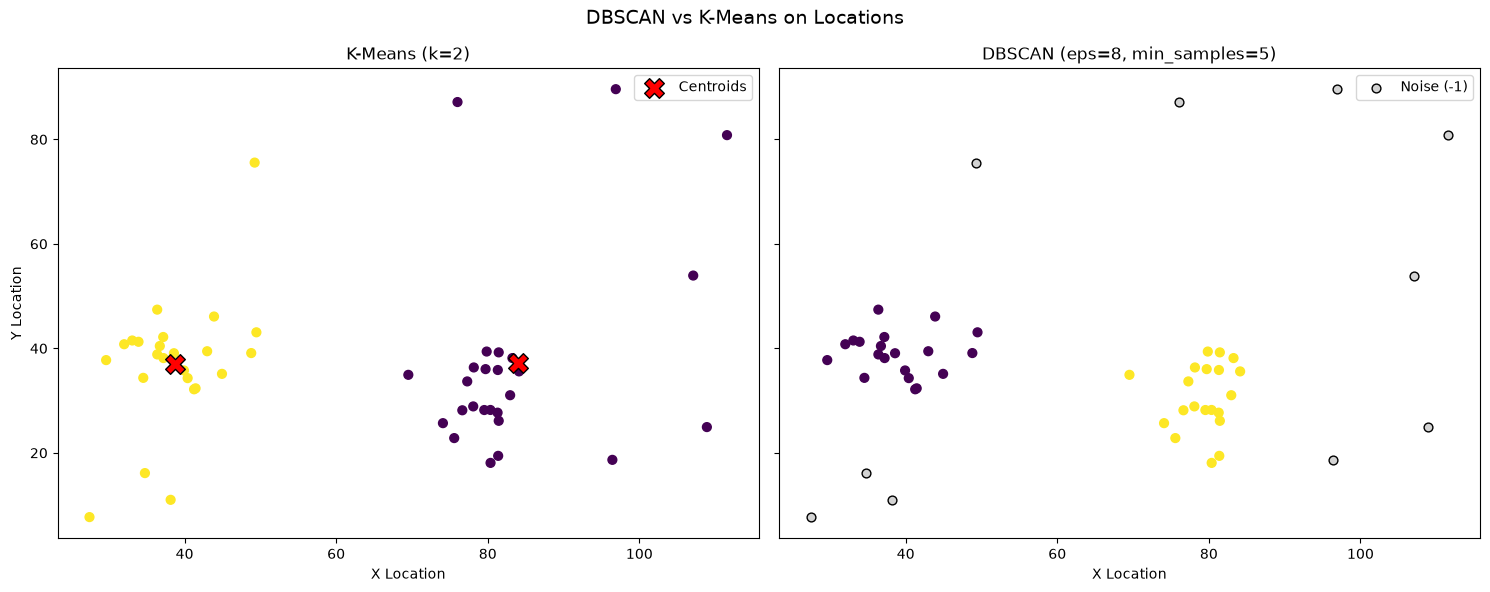

In [4]:
# Plot both results side by side
fig, axes = plt.subplots(1, 2, figsize=(15, 6), sharex=True, sharey=True)

# K-Means (left)
axes[0].scatter(
    df["x_location"], df["y_location"],
    c=df["kmeans_label"], cmap="viridis", s=40
)
axes[0].scatter(
    kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1],
    c="red", marker="X", s=200, edgecolor="black", label="Centroids"
)
axes[0].set_title("K-Means (k=2)")
axes[0].set_xlabel("X Location")
axes[0].set_ylabel("Y Location")
axes[0].legend()

# DBSCAN (right) — noise (-1) shown in grey
noise_mask = df["dbscan_label"] == -1
axes[1].scatter(
    df.loc[~noise_mask, "x_location"], df.loc[~noise_mask, "y_location"],
    c=df.loc[~noise_mask, "dbscan_label"], cmap="viridis", s=40
)
axes[1].scatter(
    df.loc[noise_mask, "x_location"], df.loc[noise_mask, "y_location"],
    c="lightgrey", s=40, edgecolor="black", label="Noise (-1)"
)
axes[1].set_title("DBSCAN (eps=8, min_samples=5)")
axes[1].set_xlabel("X Location")
axes[1].legend()

plt.suptitle("DBSCAN vs K-Means on Locations", fontsize=14)
plt.tight_layout()
plt.show()